In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import joblib

In [2]:
df = pd.read_csv("final_data.csv", low_memory=False)
df.head()

,performance_score,offensive_skill,defensive_skill,efficiency,aggression,mistake_penalty,experience,physical_index,game_type,player_name,Selected
0,-0.124196,-0.8277993019909841,-0.8246205859249759,-0.923196,-0.9200844481915191,0.865945,0.0,0.0,Cricket,Player_0,1
1,-0.077223,-0.8277993019909841,0.5490061582842831,-0.352970,-0.7651858259817703,-0.633086,0.0,0.0,Cricket,Player_1,1
2,-1.533367,-1.189937080634515,0.8924128443365978,-0.630985,-0.7083896645048627,-2.506875,0.0,0.0,Cricket,Player_2,0
3,-1.549024,-1.4313622663968693,-2.5416540161865497,-1.833758,-1.808169882194077,1.240703,0.0,0.0,Cricket,Player_3,0
4,-0.108538,-0.344948930466276,0.8924128443365978,-0.640333,-0.9097578733775357,-1.007844,0.0,0.0,Cricket,Player_4,1


In [3]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["game_type"] = encoder.fit_transform(df["game_type"])

In [4]:
X = df.drop(["Selected","player_name","performance_score"], axis=1)
y = df["Selected"]

In [5]:
X.dtypes

offensive_skill     object
defensive_skill     object
efficiency         float64
aggression          object
mistake_penalty    float64
experience         float64
physical_index     float64
game_type            int64
dtype: object

In [6]:
X = df.drop(["Selected","performance_score","player_name"], axis=1)

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(X.mean())

y = df["Selected"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9322547071624563


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     19078
           1       0.95      0.88      0.91     12629

    accuracy                           0.93     31707
   macro avg       0.94      0.92      0.93     31707
weighted avg       0.93      0.93      0.93     31707



In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[18464   614]
 [ 1534 11095]]


In [13]:
importance = pd.DataFrame({
    "Feature": df.drop(columns=["Selected","performance_score","player_name"]).columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
0,offensive_skill,0.365248
1,defensive_skill,0.212447
3,aggression,0.148096
5,experience,0.096857
2,efficiency,0.092697
7,game_type,0.045805
6,physical_index,0.027429
4,mistake_penalty,0.011420


In [14]:
def predict_player(player_name, sport):

    sport_encoded = encoder.transform([sport])[0]

    player = df[
        (df["player_name"] == player_name) &
        (df["game_type"] == sport_encoded)
    ]

    if player.empty:
        print("Player not found")
        return

    player_features = player.drop(columns=["player_name","Selected"])

    player_features = player_features.apply(pd.to_numeric, errors="coerce").fillna(0)

    player_features = scaler.transform(player_features)

    prediction = best_model.predict(player_features)

    if prediction[0] == 1:
        print("Selected")
    else:
        print("Not Selected")

In [15]:
df["player_name"].head()

0    Player_0
1    Player_1
2    Player_2
3    Player_3
4    Player_4
Name: player_name, dtype: object

In [16]:
player = df[
    df["player_name"] == "Player_25"
]

player
# print(player)

,performance_score,offensive_skill,defensive_skill,efficiency,aggression,mistake_penalty,experience,physical_index,game_type,player_name,Selected
25,-1.173245,-2.2763504165651085,0.20559947223196834,-0.655221,-1.0078603341103762,-2.132117,0.0,0.0,2,Player_25,0


In [17]:
def find_player(player_name):

    player = df[
        df["player_name"] == player_name
    ]
def predict_player(player_name):

    player = df[
        df["player_name"] == player_name
    ]

    if player.empty:
        print("Player not found")
        return

    player_features = player.drop(columns=["player_name","Selected"])

    player_features = scaler.transform(player_features)

    prediction = best_model.predict(player_features)

    if prediction[0] == 1:
        print("Selected")
    else:
        print("Not Selected")
    print(player)

In [18]:
def find_player(player_name):
    
    player = df[
        df["player_name"] == "player_255"
]

find_player("player_255")

In [19]:
print(find_player("player_255"))

None


In [20]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),

    # "SVM": SVC()

    # "KNN": KNeighborsClassifier()

}

In [21]:
results = {}
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy
    trained_models[name] = model

    print(name,"Accuracy:",accuracy)

Logistic Regression Accuracy: 0.7752862144006055
Random Forest Accuracy: 0.9320023969470463


# Model Comparision

In [22]:
comparison = pd.DataFrame(
    list(results.items()),
    columns=["Model","Accuracy"]
)

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.775286
1        Random Forest  0.932002


In [23]:
best_model_name = max(results, key=results.get)

best_model = trained_models[best_model_name]

print("Best Model:",best_model_name)

Best Model: Random Forest


# Confusion Matrix

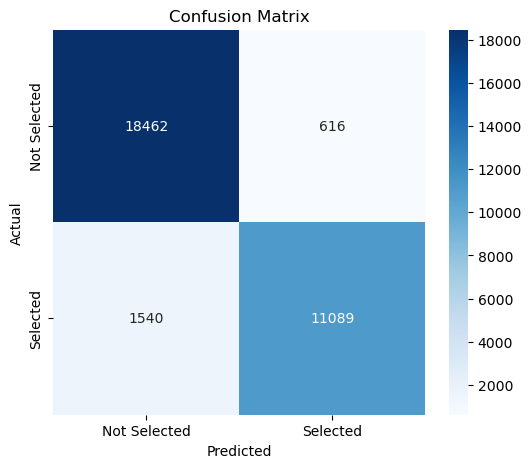

In [24]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Selected","Selected"],
    yticklabels=["Not Selected","Selected"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94     19078
           1       0.95      0.88      0.91     12629

    accuracy                           0.93     31707
   macro avg       0.94      0.92      0.93     31707
weighted avg       0.93      0.93      0.93     31707



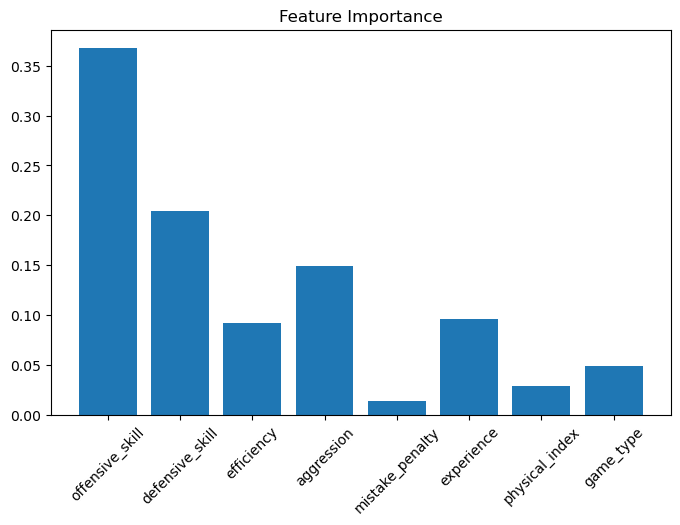

In [26]:
if best_model_name == "Random Forest":

    importance = best_model.feature_importances_

    plt.figure(figsize=(8,5))

    plt.bar(X.columns, importance)

    plt.xticks(rotation=45)

    plt.title("Feature Importance")

    plt.show()

# Top 5 Player Recommendation

In [27]:
def top_players_by_sport(sport, n=5):

    sport_encoded = encoder.transform([sport])[0]

    sport_df = df[df["game_type"] == sport_encoded]

    top_players = sport_df.sort_values(
        by="performance_score",
        ascending=False
    ).head(n)

    top_players["sport"] = sport

    return top_players[["player_name","sport","performance_score"]]

In [28]:
top_players_by_sport("Golf",5)

,player_name,sport,performance_score
91963,Player_91963,Golf,50.0
91964,Player_91964,Golf,45.0
91965,Player_91965,Golf,44.0
91966,Player_91966,Golf,43.0
97650,Player_97650,Golf,43.0


# Best Player Prediction

In [29]:
train_columns = X.columns

In [30]:
def predict_player(player_name):

    player = df[df["player_name"] == player_name]

    if player.empty:
        print("Player not found")
        return

    # ❌ remove unwanted columns (IMPORTANT)
    player_features = player.drop(
        columns=["player_name","Selected","performance_score"],
        errors="ignore"
    )

    # numeric conversion
    player_features = player_features.apply(pd.to_numeric, errors="coerce").fillna(0)

    # ✅ ensure same column order
    player_features = player_features[train_columns]

    # scaling (agar use kiya tha)
    player_features = scaler.transform(player_features)

    prediction = best_model.predict(player_features)

    if prediction[0] == 1:
        print(f"{player_name} → Selected ✅")
    else:
        print(f"{player_name} → Not Selected ❌")

In [31]:
predict_player("Player_255")

Player_255 → Selected ✅


# Player Comparision Tool

In [32]:
columns = X.columns

In [33]:
def compare_players(player1, player2):

    p1 = df[df["player_name"] == player1]
    p2 = df[df["player_name"] == player2]

    if p1.empty or p2.empty:
        print("Player not found")
        return

    # ❗ IMPORTANT: drop extra columns
    drop_cols = ["player_name", "Selected", "performance_score"]

    p1_feat = p1.drop(columns=drop_cols, errors="ignore")
    p2_feat = p2.drop(columns=drop_cols, errors="ignore")

    # numeric convert
    p1_feat = p1_feat.apply(pd.to_numeric, errors="coerce").fillna(0)
    p2_feat = p2_feat.apply(pd.to_numeric, errors="coerce").fillna(0)

    # ✅ SAME ORDER + SAME FEATURES
    p1_feat = p1_feat.reindex(columns=columns, fill_value=0)
    p2_feat = p2_feat.reindex(columns=columns, fill_value=0)

    # scaling
    p1_feat = scaler.transform(p1_feat)
    p2_feat = scaler.transform(p2_feat)

    # prediction
    pred1 = best_model.predict(p1_feat)[0]
    pred2 = best_model.predict(p2_feat)[0]

    print(f"{player1} → {'Selected ✅' if pred1==1 else 'Not Selected ❌'}")
    print(f"{player2} → {'Selected ✅' if pred2==1 else 'Not Selected ❌'}")

In [34]:
compare_players("Player_10","Player_1115")

Player_10 → Not Selected ❌
Player_1115 → Selected ✅


# Top 10 Players Dashboard

In [35]:
def top_players(n=10):

    temp_df = df.copy()

    # ❗ extra columns remove
    drop_cols = ["player_name", "Selected", "performance_score"]

    features = temp_df.drop(columns=drop_cols, errors="ignore")

    # numeric convert
    features = features.apply(pd.to_numeric, errors="coerce").fillna(0)

    # ✅ SAME features + SAME order
    features = features.reindex(columns=columns, fill_value=0)

    # scaling
    features_scaled = scaler.transform(features)

    # prediction
    predictions = best_model.predict(features_scaled)

    temp_df["Prediction"] = predictions

    # sirf selected players
    selected_players = temp_df[temp_df["Prediction"] == 1]

    # top by performance_score
    top_players = selected_players.sort_values(
        by="performance_score",
        ascending=False
    ).head(n)

    return top_players[["player_name","performance_score"]]

In [36]:
top_players(10)

,player_name,performance_score
149829,Player_149829,134.0
149830,Player_149830,128.0
149831,Player_149831,125.0
149828,Player_149828,122.0
149896,Player_149896,121.0
149838,Player_149838,118.0
149839,Player_149839,114.0
149849,Player_149849,111.0
149844,Player_149844,110.0
149846,Player_149846,107.0


NameError: name 'game_type' is not defined